# SPX Stock Price Prediction Using Unscented Kalman Filter 

In [1]:
import sys
import warnings

if not sys.warnoptions:
    warnings.simplefilter('ignore')

In [29]:
import numpy as np
import pandas as pd

#Plotting and Visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import MinMaxScaler

#from statsmodels.tsa.stattools import acf, pacf, q_stat, adfuller, grangercausalitytests
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



In [4]:
import platform
print(f"Python version: {platform.python_version()}")
print(f"numpy version: {np.__version__}")
print(f"panda version: {pd.__version__}")
print(f"seaborn version: {sns.__version__}")
import matplotlib
print(f"matplotlib version: {matplotlib.__version__}")
#import statsmodels
#print(f"statsmodel version: {statsmodels.__version__}")
#import scipy
#print(f"scipy version: {scipy.__version__}")
import sklearn 
print(f"sklearn version: {sklearn. __version__}")


Python version: 3.12.3
numpy version: 1.26.4
panda version: 2.1.4
seaborn version: 0.13.2
matplotlib version: 3.7.5
sklearn version: 1.4.2


## Gather Historical Data

In [66]:
ticker_symbol = "^SPX"  #  S&P500 Index 
start_date = "2000-01-03"
end_date = "2026-01-23"

# I use =GOOGLEFINANCE("INDEXSP:.INX", "all",DATE(2000,1,1),today())  on google sheet
stock_data = pd.read_csv('./SP500-SPX.csv')
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
stock_data.set_index("Date", inplace=True)
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6557 entries, 2000-01-03 16:00:00 to 2026-01-23 16:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    6557 non-null   float64
 1   High    6557 non-null   float64
 2   Low     6557 non-null   float64
 3   Close   6557 non-null   float64
 4   Volume  6557 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 307.4 KB


In [9]:
stock_data.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-01-16 16:00:00,6960.54,6967.30,6925.09,6940.01,0
2026-01-20 16:00:00,6865.24,6871.17,6789.05,6796.86,0
2026-01-21 16:00:00,6810.71,6910.39,6804.96,6875.62,0
2026-01-22 16:00:00,6914.44,6934.75,6893.62,6913.35,0
2026-01-23 16:00:00,6907.85,6932.96,6895.50,6915.61,0


In [10]:
stock_data.isnull().sum(axis=0) # check any NA

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## Exploratory Data Analysis (EDA)

In [11]:
stock_data.describe()

,Open,High,Low,Close,Volume
count,6557.000000,6557.000000,6557.000000,6557.000000,6557.0
mean,2276.229452,2289.172137,2262.320930,2276.587680,0.0
std,1468.141601,1474.882218,1460.871067,1468.417376,0.0
min,679.280000,695.270000,666.790000,676.530000,0.0
25%,1210.340000,1218.110000,1203.610000,1210.650000,0.0
50%,1525.200000,1532.460000,1518.740000,1525.420000,0.0
75%,2894.150000,2904.650000,2879.130000,2888.680000,0.0
max,6977.410000,6986.330000,6938.770000,6977.270000,0.0


In [18]:
import plotly
print(plotly.__version__)

5.22.0


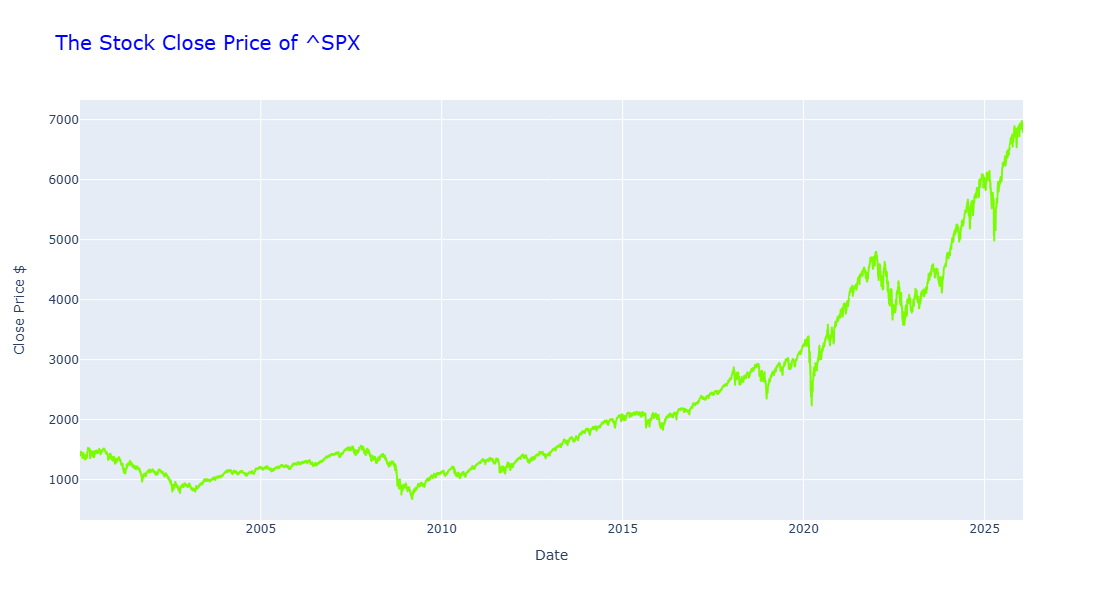

In [19]:
import plotly.express as px

fig = px.line(stock_data, x=stock_data.index, y='Close', title=f'The Stock Close Price of {ticker_symbol}',
              labels={'Close': 'Close Price $'},
              template='plotly', width=1000, height=600)
fig.update_traces(line_color='lawngreen')
fig.update_layout(title_font_color='blue', title_font_size=20)
fig.show()

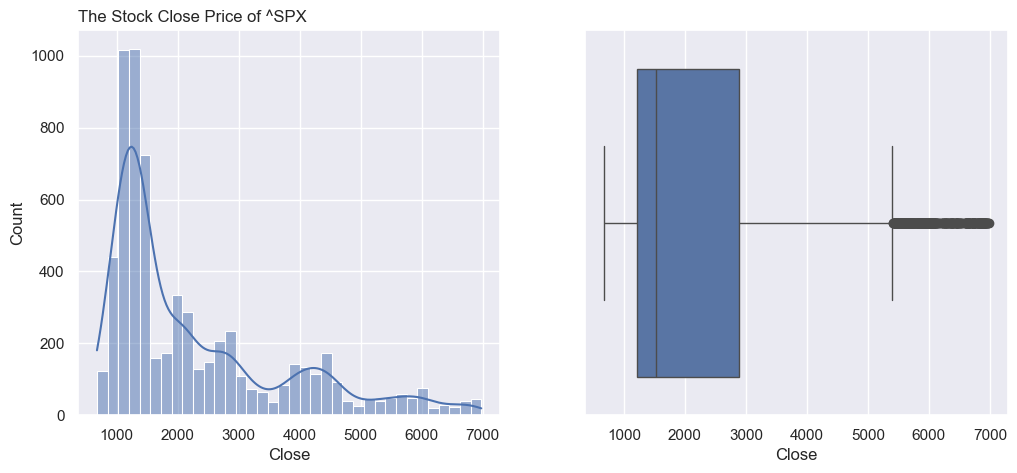

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title(f'The Stock Close Price of {ticker_symbol}', loc='left')
sns.histplot(stock_data['Close'], kde=True)
plt.subplot(1,2,2)
sns.boxplot(stock_data['Close'] , orient="h")
plt.show()


In [21]:
# https://filterpy.readthedocs.io/en/latest/index.html
# !pip install filterpy

In [22]:
import filterpy
filterpy.__version__

'1.4.5'

### Save last 15 points for predictions comparison

In [37]:
close_prices = stock_data[['Close']][:-15]

In [38]:
close_prices.head()

,Close
Date,
2000-01-03 16:00:00,1455.17
2000-01-04 16:00:00,1399.42
2000-01-05 16:00:00,1402.11
2000-01-06 16:00:00,1403.46
2000-01-07 16:00:00,1441.46


In [39]:
close_prices.tail()

,Close
Date,
2025-12-24 13:00:00,6932.05
2025-12-26 16:00:00,6929.94
2025-12-29 16:00:00,6905.74
2025-12-30 16:00:00,6896.24
2025-12-31 16:00:00,6845.50


In [40]:
tmp_df = close_prices.copy()
tmp_df['Daily Return'] = tmp_df.pct_change()
tmp_df.dropna(inplace=True)
tmp_df.describe()

,Close,Daily Return
count,6541.000000,6541.000000
mean,2266.069823,0.000311
std,1453.237762,0.012188
min,676.530000,-0.119841
25%,1210.200000,-0.004725
50%,1522.970000,0.000623
75%,2884.430000,0.005874
max,6932.050000,0.115800


## Perform a grid search for optimal parameters

### Split data into training and testing sets for Grid searching purpose

### Note: change the var number if necessary. My number is based on daily return of SPX close price.
    ukf.Q = Q_discrete_white_noise(dim=n_dim_state, dt=dt, var=0.0001485) * Q 

In [30]:
# Split data into training and testing sets
train_data, test_data = train_test_split(close_prices, test_size=0.2, shuffle=False)

In [31]:
print(train_data.shape, test_data.shape)

(5233,) (1309,)


In [41]:
from filterpy.kalman import UnscentedKalmanFilter, MerweScaledSigmaPoints
from filterpy.common import Q_discrete_white_noise
from itertools import product
import time  
 
start_time = time.time()  

# UKF setup
dt = 1.0   # Assuming daily interval (or adjust as per your data frequency)
n_dim_state = 2  # price and velocity
n_dim_meas = 1  # only measuring price

# Grid search for best parameters
alpha_values = [0.001, 0.01, 0.05, 0.1]
beta_values = [1.0, 2.0, 3.0, 4.0] 
kappa_values = [0, 1, 1]    # [0, 1, 3-n] (where n is the state dimension)

P_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
Q_values = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
R_values = [0.01, 0.1, 0.5, 1.0]

# Calculate velocity (price change)
#velocity = np.diff(close_prices)
#close_prices = close_prices[1:]  # Remove the first element to match velocity length

# Define state transition function
def fx(x, dt):
    # Simple model assuming constant velocity, x[0] is price, x[1] is price change rate
    return np.array([x[0] + x[1] * dt, x[1]])

# Define measurement function
def hx(x):
    return np.array([x[0]])  # We only measure the price for simplicity

# Grid search
best_r2 = -np.inf
best_params = None

# Grid search over all parameter combinations
for alpha, beta, kappa, P, Q, R in product(alpha_values, beta_values, kappa_values, P_values, Q_values, R_values):
    # Initialize sigma points and UKF with current parameter set
    sigma_points = MerweScaledSigmaPoints(n=n_dim_state, alpha=alpha, beta=beta, kappa=kappa)   
    ukf = UnscentedKalmanFilter(dim_x=n_dim_state, dim_z=n_dim_meas, fx=fx, hx=hx, dt=dt, points=sigma_points)

    # Set covariance matrices for current parameter set
    # an identity matrix scaled by a constant
    ukf.P = np.eye(n_dim_state) * P
    #ukf.Q = np.eye(n_dim_state) * Q
    ukf.Q = Q_discrete_white_noise(dim=n_dim_state, dt=dt, var=0.0001485) * Q   # var=std^2 , I based on std = 0.012188 of daily return of close price
    ukf.R = np.eye(n_dim_meas) * R


    # Initialize state (assuming initial price is known and velocity is zero)
    ukf.x = np.array([train_data[0], 0])     # train_data[0] is on 2000-01-03

    # Run filter over data and collect predictions
    predictions = []
    for z in train_data:
        ukf.predict() # Predicts the next state based on the model.
        ukf.update(z) # Updates the state estimate with the actual closing price.
        predictions.append(ukf.x[0])

    r2 = r2_score(train_data, predictions)
    
    if r2 > best_r2:
        best_r2 = r2
        best_params = (alpha, beta, kappa, P, Q, R)

print(f"Best R-squared: {best_r2}")
print(f"Best parameters: alpha={best_params[0]}, beta={best_params[1]}, kappa={best_params[2]}, P={best_params[3]}, Q={best_params[4]}, R={best_params[5]}")

print("\n")
end_time = time.time()  
execution_time = end_time - start_time  
hours, remainder = divmod(execution_time, 3600)  
minutes, seconds = divmod(remainder, 60)  
  
print(f"Execution time for grid search: {int(hours)} hours, {int(minutes)} minutes, {int(seconds)} seconds")

Best R-squared: 0.9994963122279713
Best parameters: alpha=0.001, beta=4.0, kappa=0, P=10.0, Q=1.0, R=0.01


Execution time for grid search: 1 hours, 38 minutes, 30 seconds


# Apply the best parameters to the UKF model for prediction without visual (Graph)

### Based on above grid search, the best parameters are alpha=0.001, beta=4.0, kappa=0, P=10.0, Q=1.0, R=0.01

### Notes:  These parameters may vary depend on type of time-series and its length. 
    This example is based on SPX closing price from 2000-01-03 to 2025-12-31

<p style="color: red; font-size: 20px;">The UKF model prediction is "based on the current estimate and the system’s dynamics".</p>


### Unless I can obtain hourly stock price data from a financial institute, I can only use the last portion of closing price as the initial points (current estimate).

In [60]:
start_data = close_prices['Close'][-30:]

In [61]:
start_data

Date
2025-11-18 16:00:00    6617.32
2025-11-19 16:00:00    6642.16
2025-11-20 16:00:00    6538.76
2025-11-21 16:00:00    6602.99
2025-11-24 16:00:00    6705.12
2025-11-25 16:00:00    6765.88
2025-11-26 16:00:00    6812.61
2025-11-28 13:00:00    6849.09
2025-12-01 16:00:00    6812.63
2025-12-02 16:00:00    6829.37
2025-12-03 16:00:00    6849.72
2025-12-04 16:00:00    6857.12
2025-12-05 16:00:00    6870.40
2025-12-08 16:00:00    6846.51
2025-12-09 16:00:00    6840.51
2025-12-10 16:00:00    6886.68
2025-12-11 16:00:00    6901.00
2025-12-12 16:00:00    6827.41
2025-12-15 16:00:00    6816.51
2025-12-16 16:00:00    6800.26
2025-12-17 16:00:00    6721.43
2025-12-18 16:00:00    6774.76
2025-12-19 16:00:00    6834.50
2025-12-22 16:00:00    6878.49
2025-12-23 16:00:00    6909.79
2025-12-24 13:00:00    6932.05
2025-12-26 16:00:00    6929.94
2025-12-29 16:00:00    6905.74
2025-12-30 16:00:00    6896.24
2025-12-31 16:00:00    6845.50
Name: Close, dtype: float64

In [62]:
from filterpy.kalman import UnscentedKalmanFilter
from filterpy.kalman import MerweScaledSigmaPoints
from filterpy.common import Q_discrete_white_noise

# UKF setup
dt = 1.0   # Assuming daily interval (or adjust as per your data frequency)
n_dim_state = 2  # price and velocity
n_dim_meas = 1  # only measuring price

# Define the state transition function
def fx(x, dt):
    return np.array([x[0] + dt * x[1], x[1]])

# Define the measurement function
def hx(x):
    return np.array([x[0]])
#
# Assuming you have found the best parameters from the grid search
# ================================================================
#
# 
# Best parameters: alpha=0.001, beta=4.0, kappa=0, P=10.0, Q=1.0, R=0.01
best_params = {'alpha': 0.001, 'beta': 4.0, 'kappa': 0, 'P': 10, 'Q': 1.0, 'R': 0.01}

# Initialize the UKF with the best parameters
alpha, beta, kappa = best_params['alpha'], best_params['beta'], best_params['kappa']
P, Q, R = best_params['P'], best_params['Q'], best_params['R']

points = MerweScaledSigmaPoints(n=n_dim_state, alpha=alpha, beta=beta, kappa=kappa)
ukf = UnscentedKalmanFilter(dim_x=n_dim_state, dim_z=n_dim_meas, fx=fx, hx=hx, dt=dt, points=points)
ukf.P = np.eye(n_dim_state) * P
#ukf.Q = np.eye(n_dim_state) * Q
ukf.Q = Q_discrete_white_noise(dim=n_dim_state, dt=dt, var=0.004) * Q
ukf.R = np.eye(n_dim_meas) * R
#
# using last portion of close_prices dataframe as current estimate
#
ukf.x = np.array([start_data[0], 0])    


# Forecast the next n days
filtered_states = []
# Fit the model to the test data
for z in start_data:
    ukf.predict()
    ukf.update(z)
    filtered_states.append(ukf.x.copy())

n_forecast = 15  # predict 15 points forward
predictions = []
last_state = filtered_states[-1]    # last value is on 12/31/2025 
for _ in range(n_forecast):
    last_state = fx(last_state, dt)
    predictions.append(last_state[0])



In [63]:
predictions

[6835.4627389610405,
 6810.9866210102955,
 6786.5105030595505,
 6762.0343851088055,
 6737.5582671580605,
 6713.0821492073155,
 6688.6060312565705,
 6664.1299133058255,
 6639.653795355081,
 6615.177677404336,
 6590.701559453591,
 6566.225441502846,
 6541.749323552101,
 6517.273205601356,
 6492.797087650611]

In [64]:
new_close_prices = stock_data['Close'][-15:]

In [65]:
new_df = pd.DataFrame({'Close Prices': new_close_prices,'Predicted values': predictions, 'Difference':new_close_prices- predictions})
new_df

,Close Prices,Predicted values,Difference
Date,,,
2026-01-02 16:00:00,6858.47,6835.462739,23.007261
2026-01-05 16:00:00,6902.05,6810.986621,91.063379
2026-01-06 16:00:00,6944.82,6786.510503,158.309497
2026-01-07 16:00:00,6920.93,6762.034385,158.895615
2026-01-08 16:00:00,6921.46,6737.558267,183.901733
2026-01-09 16:00:00,6966.28,6713.082149,253.197851
2026-01-12 16:00:00,6977.27,6688.606031,288.663969
2026-01-13 16:00:00,6963.74,6664.129913,299.610087
2026-01-14 16:00:00,6926.60,6639.653795,286.946205


## The first prediction value, 6835.462739 on 2026‑01‑02, is based on the previous day’s closing price (6845.50 on 2025‑12‑31) as the “current estimate” for forecasting. That initial predicted value is then used to generate the next prediction, and the process continues iteratively. As the prediction horizon extends, the deviation naturally grows unless real‑time data is available.

## If real‑time data is available, set n_forecast to 1 so the model predicts only the next point’s movement.